
===== Processing FVs_FLAIR =====
  Fold 1: train=949, valid=240
  Fold 2: train=951, valid=238
  Fold 3: train=951, valid=238
  Fold 4: train=952, valid=237
  Fold 5: train=953, valid=236

===== Processing FVs_medsiglip =====
  Fold 1: train=949, valid=240
  Fold 2: train=951, valid=238
  Fold 3: train=951, valid=238
  Fold 4: train=952, valid=237
  Fold 5: train=953, valid=236

===== Processing FVs_LLM2CLIP-openai =====
  Fold 1: train=949, valid=240
  Fold 2: train=951, valid=238
  Fold 3: train=951, valid=238
  Fold 4: train=952, valid=237
  Fold 5: train=953, valid=236

===== Processing FVs_ConceptCLIP =====
  Fold 1: train=949, valid=240
  Fold 2: train=951, valid=238
  Fold 3: train=951, valid=238
  Fold 4: train=952, valid=237
  Fold 5: train=953, valid=236

===== Processing FVs_MONET =====
  Fold 1: train=949, valid=240
  Fold 2: train=951, valid=238
  Fold 3: train=951, valid=238
  Fold 4: train=952, valid=237
  Fold 5: train=953, valid=236

===== Processing FVs_SigLIP =====


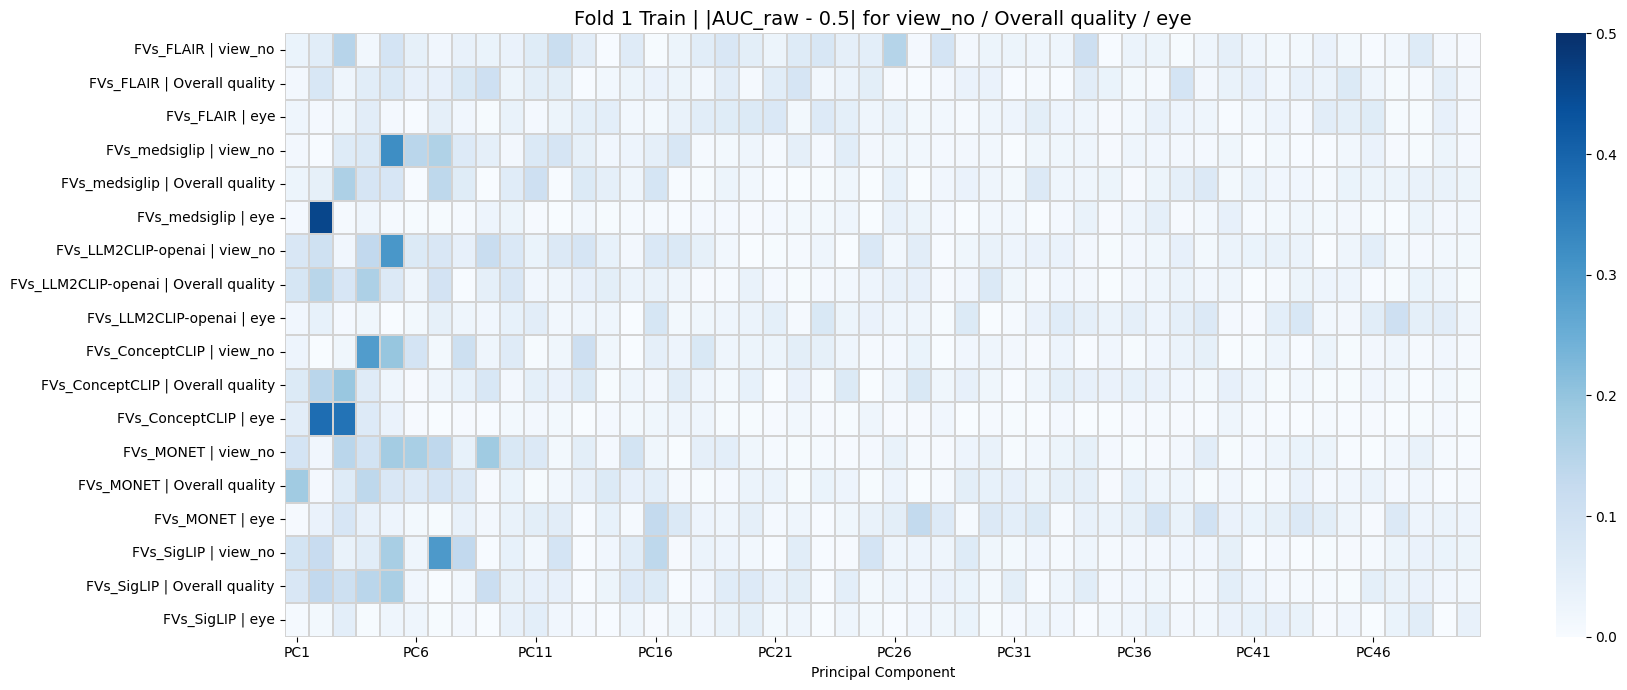

Saved: ./cv_pca_factor_heatmaps_sample\fold01_train_auc_factor_heatmap.png


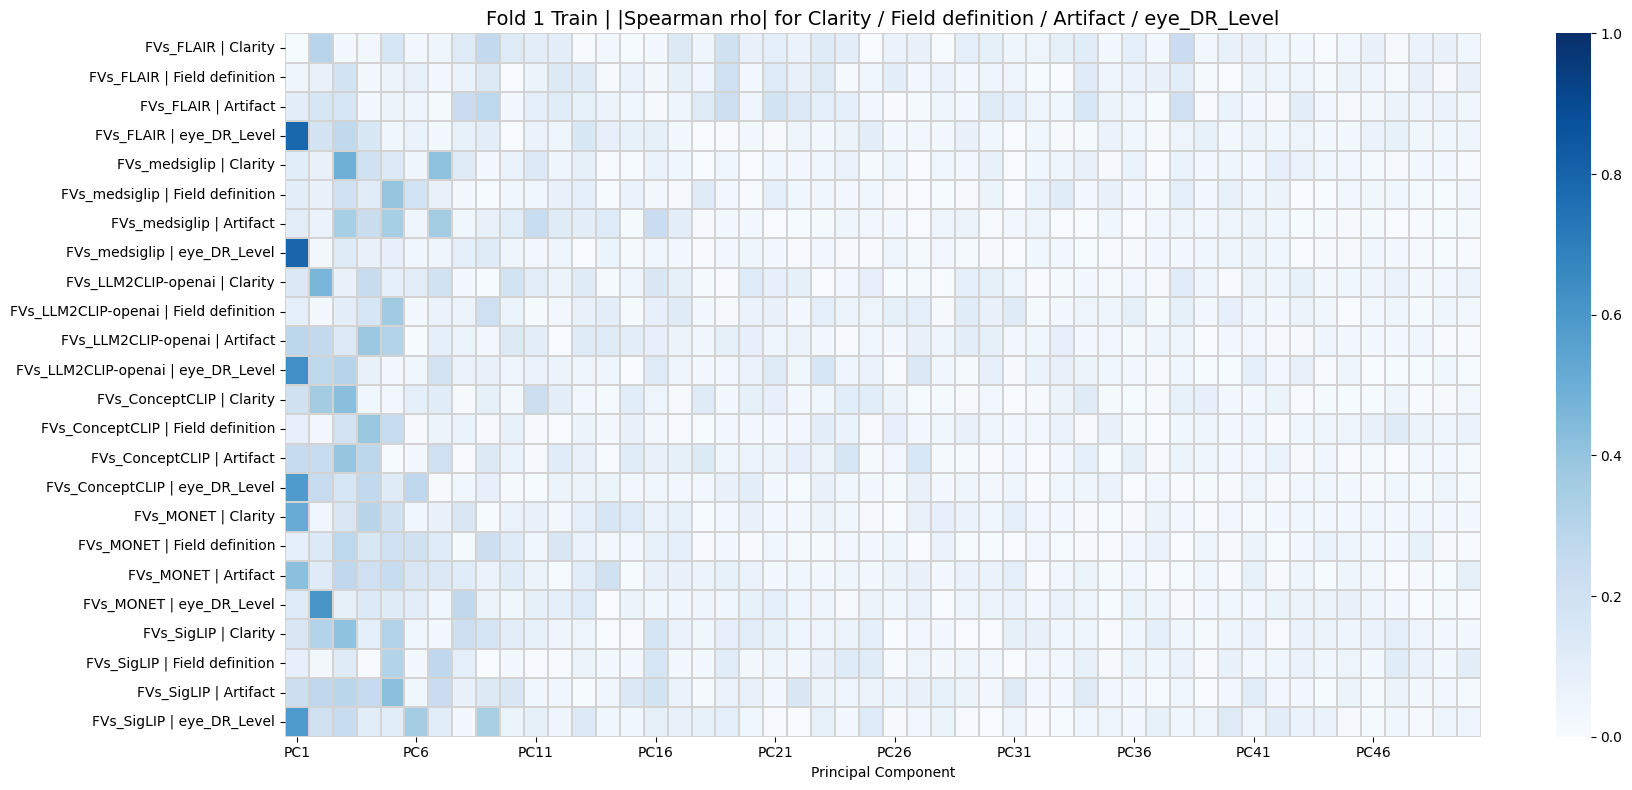

Saved: ./cv_pca_factor_heatmaps_sample\fold01_train_spearman_factor_heatmap.png

===== Plotting Fold 2 =====


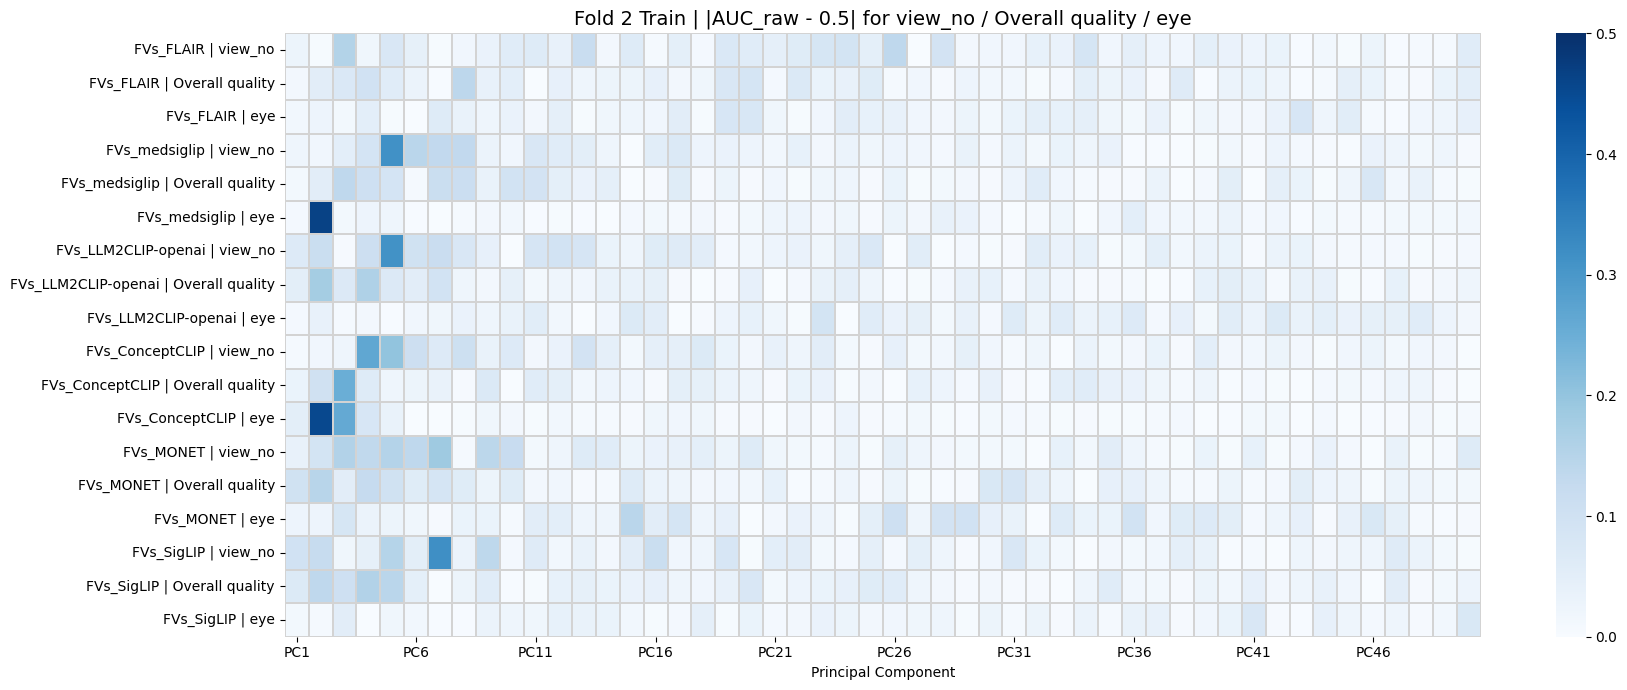

Saved: ./cv_pca_factor_heatmaps_sample\fold02_train_auc_factor_heatmap.png


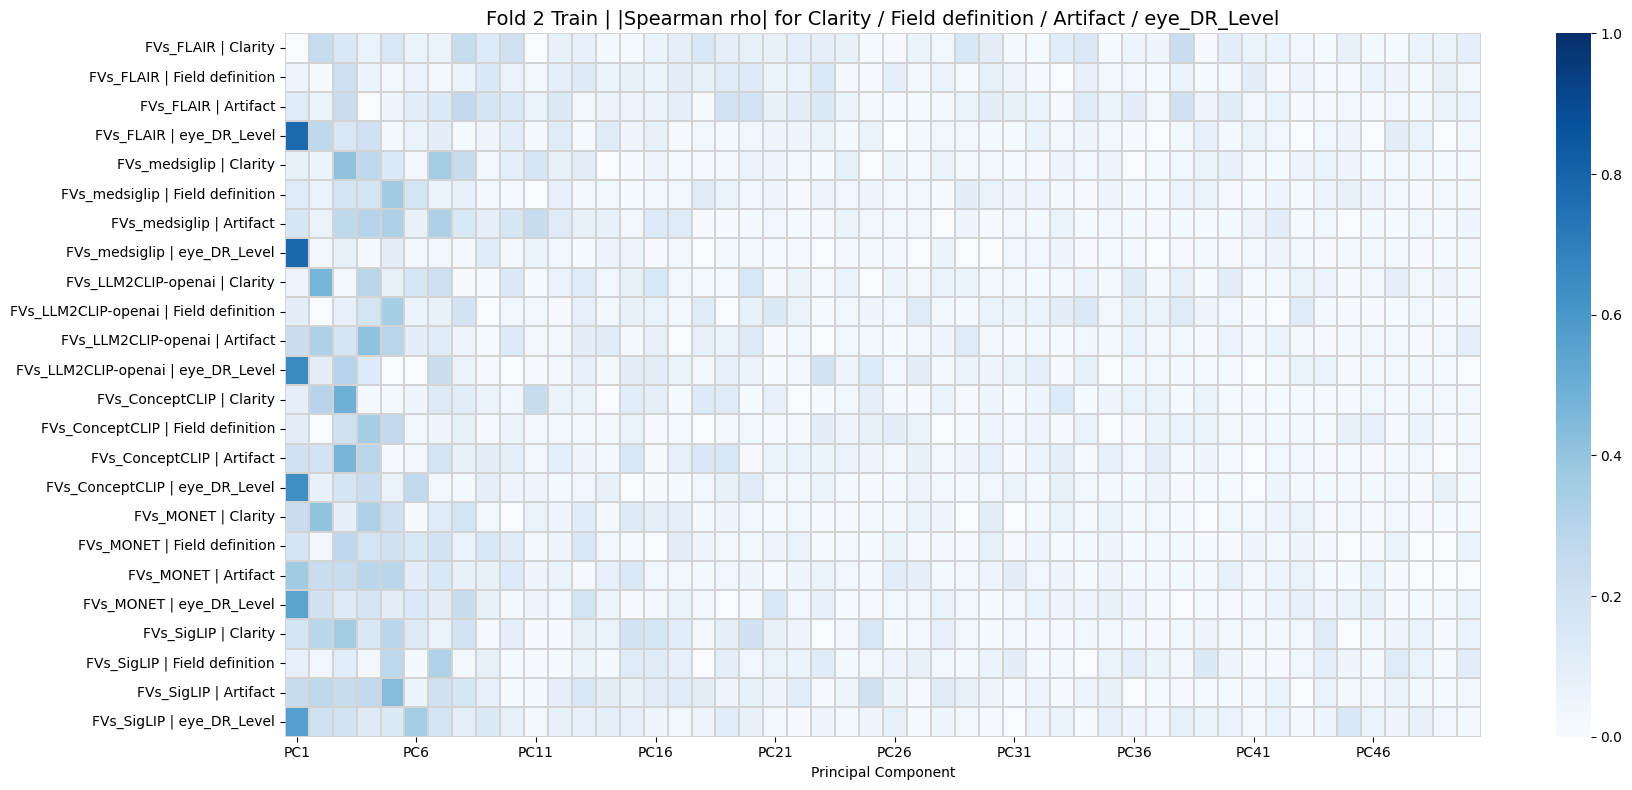

Saved: ./cv_pca_factor_heatmaps_sample\fold02_train_spearman_factor_heatmap.png

===== Plotting Fold 3 =====


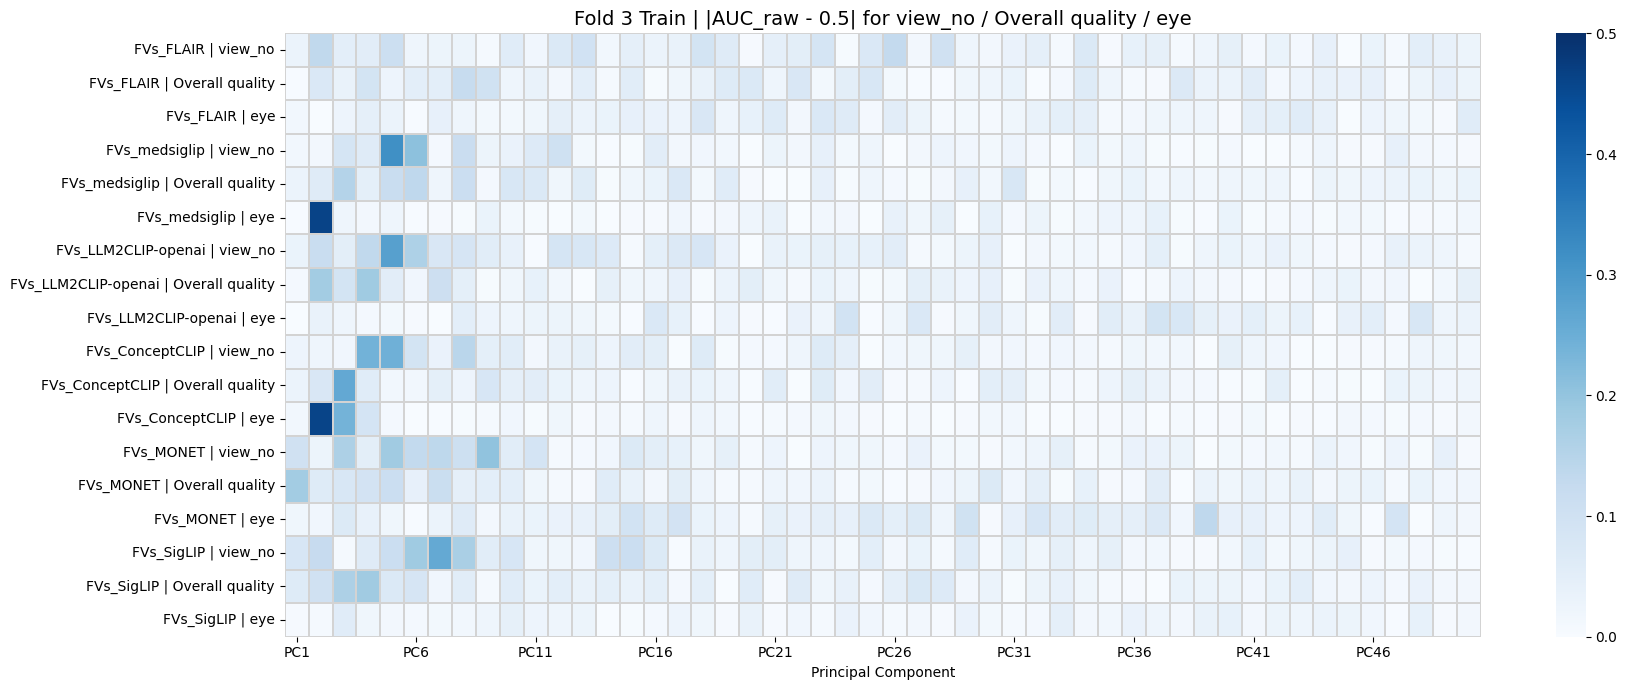

Saved: ./cv_pca_factor_heatmaps_sample\fold03_train_auc_factor_heatmap.png


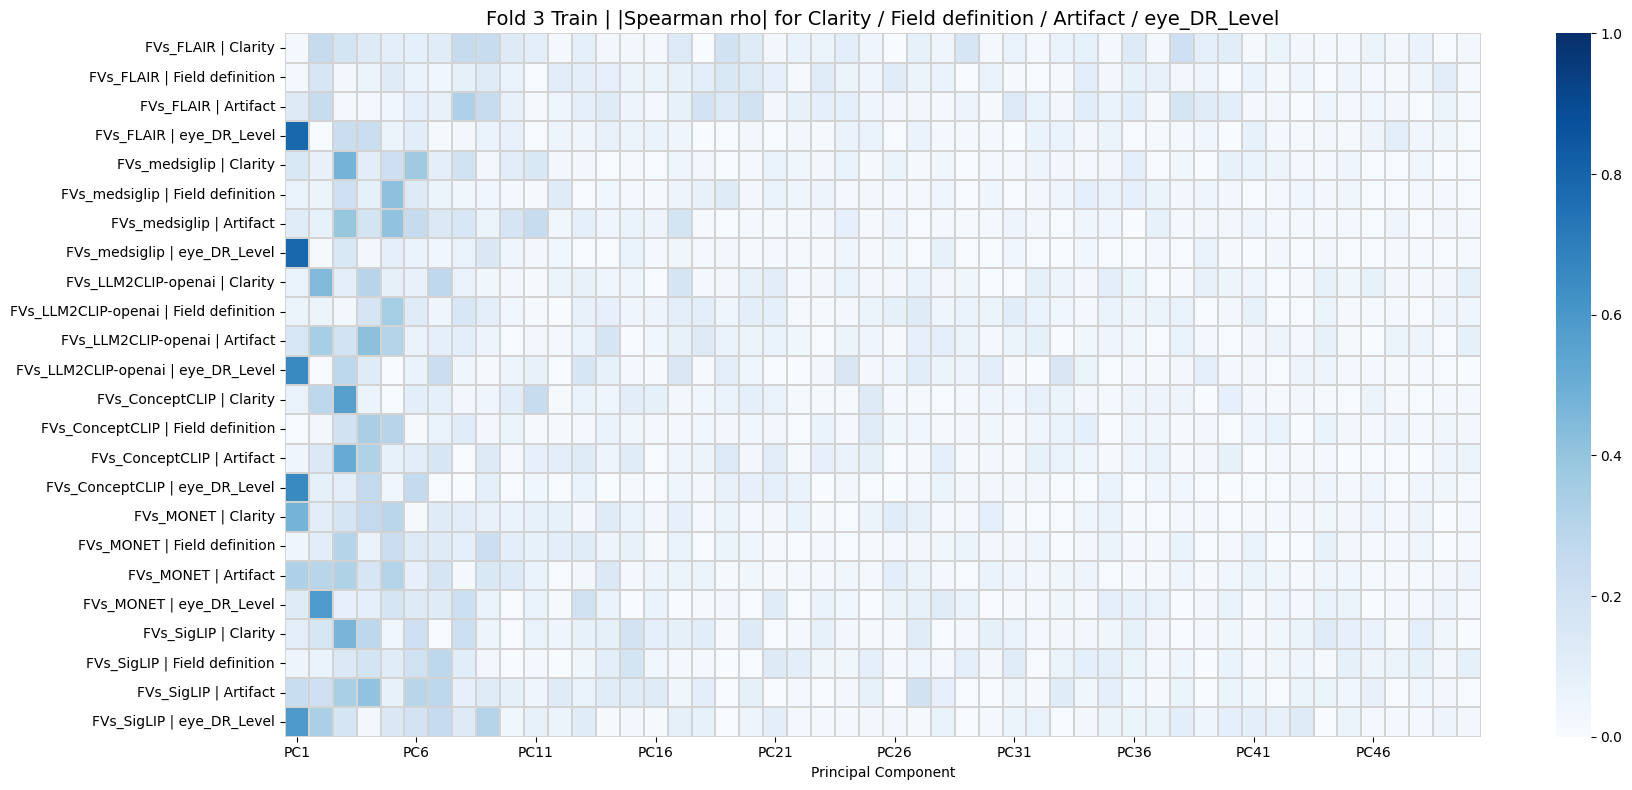

Saved: ./cv_pca_factor_heatmaps_sample\fold03_train_spearman_factor_heatmap.png

===== Plotting Fold 4 =====


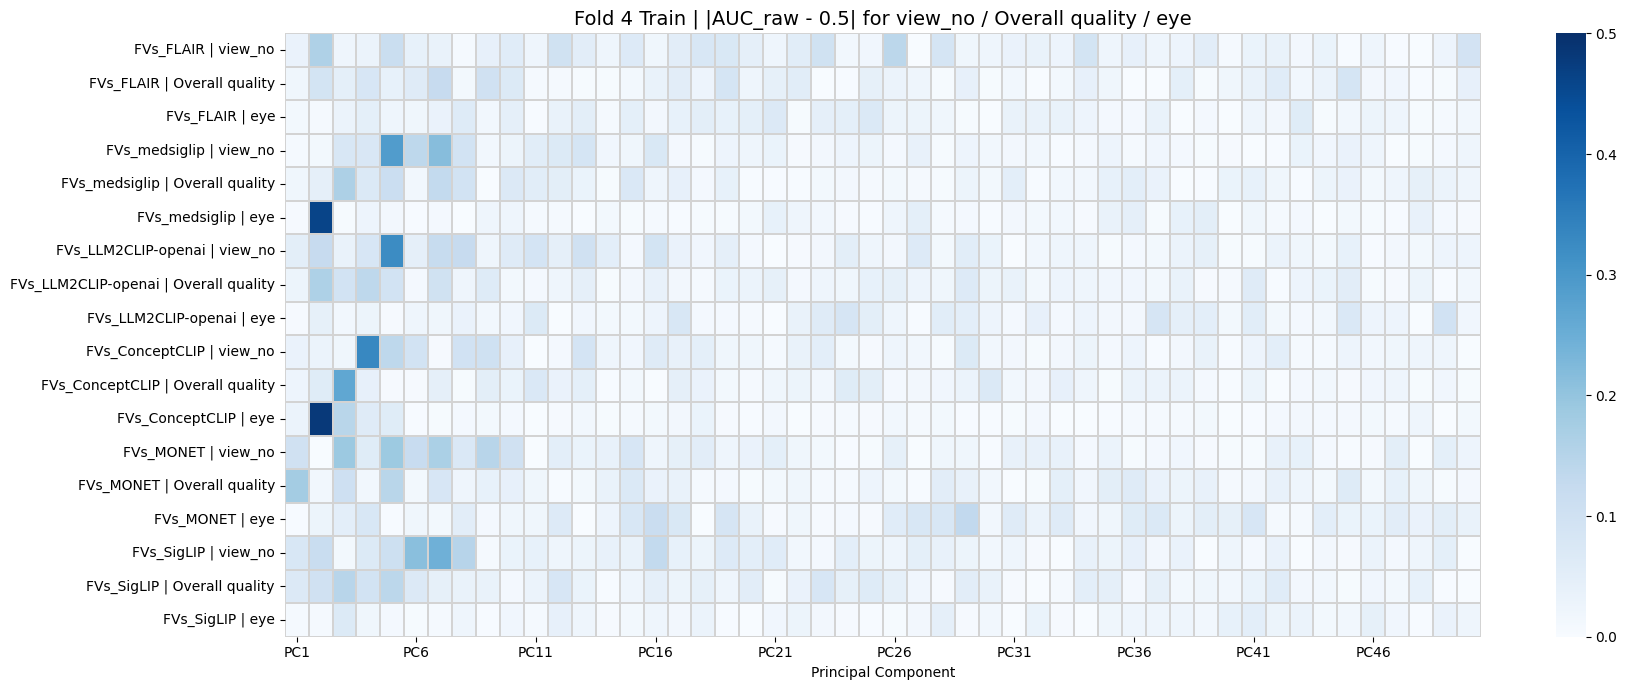

Saved: ./cv_pca_factor_heatmaps_sample\fold04_train_auc_factor_heatmap.png


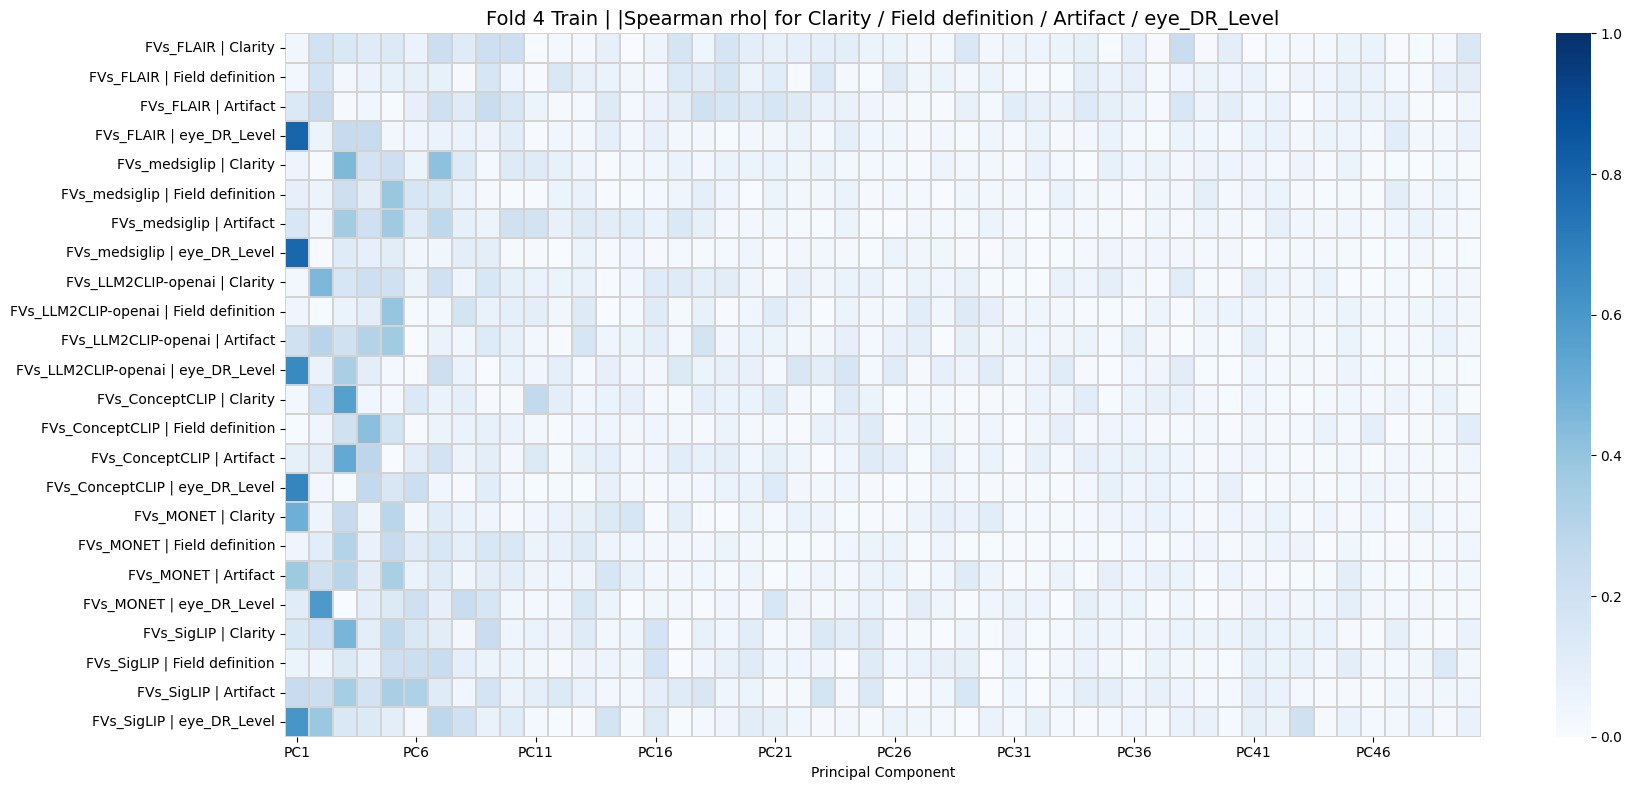

Saved: ./cv_pca_factor_heatmaps_sample\fold04_train_spearman_factor_heatmap.png

===== Plotting Fold 5 =====


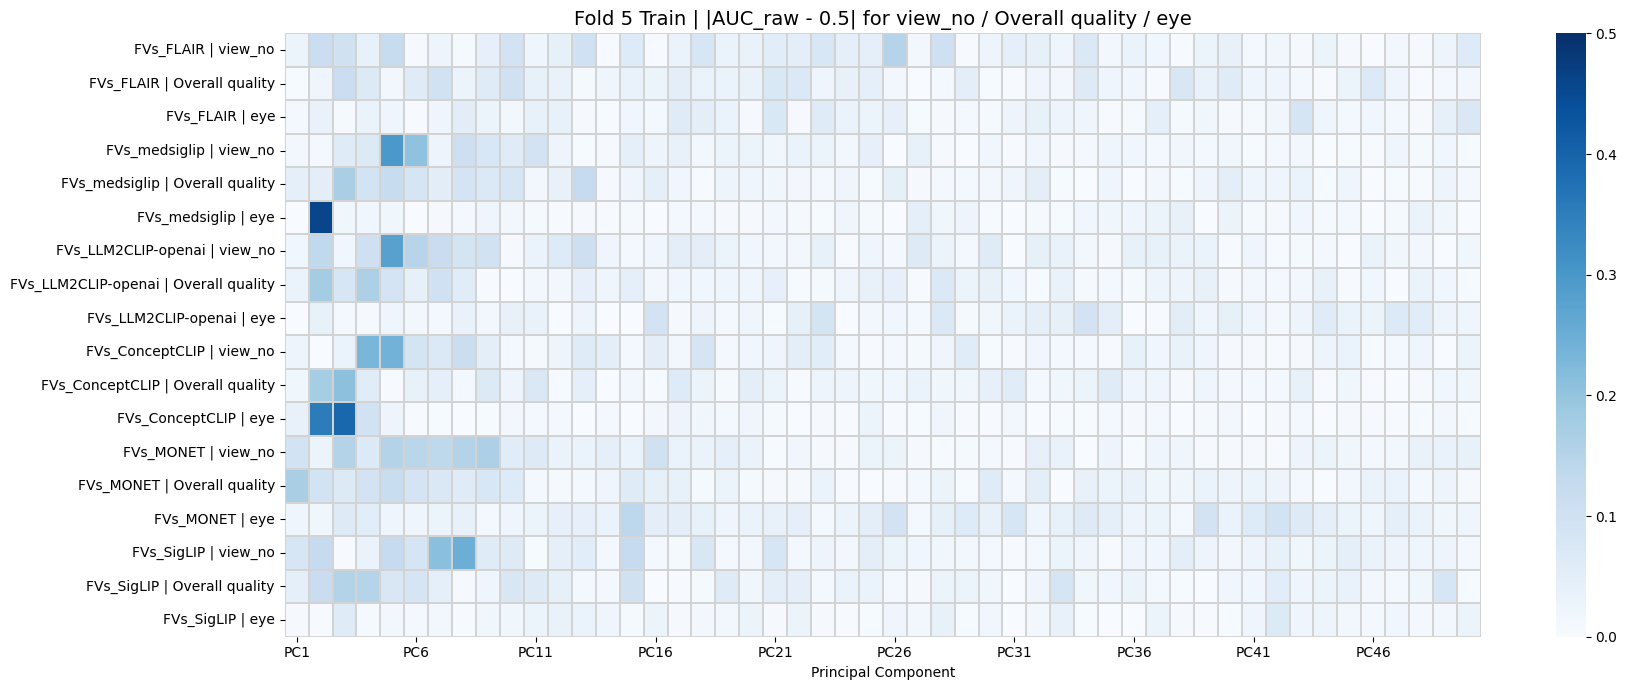

Saved: ./cv_pca_factor_heatmaps_sample\fold05_train_auc_factor_heatmap.png


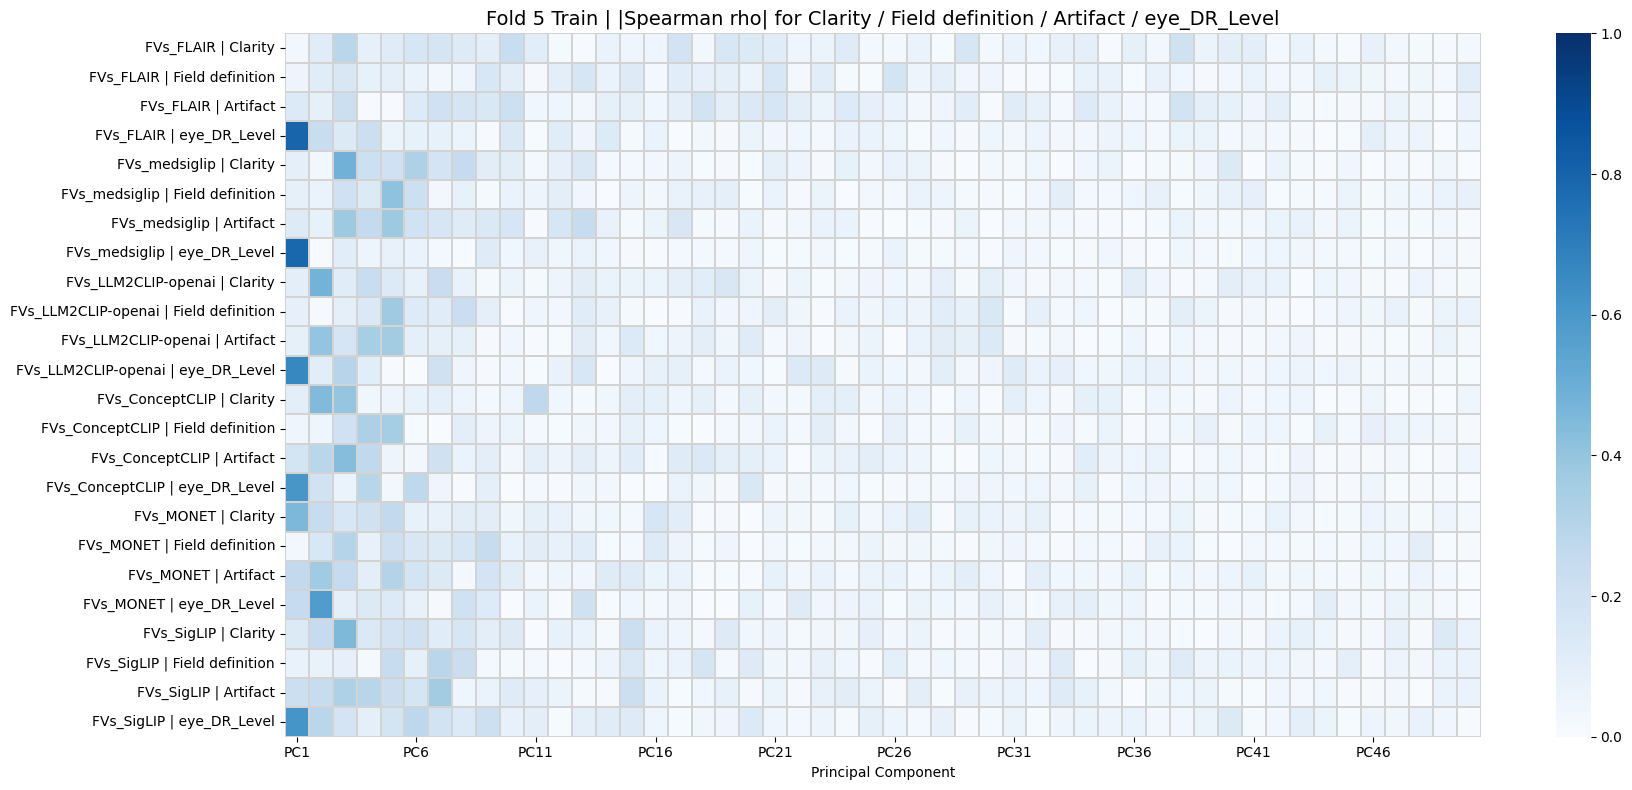

Saved: ./cv_pca_factor_heatmaps_sample\fold05_train_spearman_factor_heatmap.png


In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr


# =========================
# Config
# =========================

BASE_DIR = "./aligned_features_drvalid"

MODEL_NAMES = [
    "FVs_FLAIR",
    "FVs_medsiglip",
    "FVs_LLM2CLIP-openai",
    "FVs_ConceptCLIP",
    "FVs_MONET",
    "FVs_SigLIP",
]

N_SPLITS = 5
N_PC = 50
RANDOM_STATE = 42

GROUP_COL = "patient_id"
LABEL_COL_FOR_SPLIT = "patient_DR_Level"

AUC_FACTORS = [
    "view_no",
    "Overall quality",
    "eye",
]

SPEARMAN_FACTORS = [
    "Clarity",
    "Field definition",
    "Artifact",
    "eye_DR_Level",
]

# 样本版：先只画 Fold 1
# 全部输出时改成 None
# PLOT_FOLDS = [1]
PLOT_FOLDS = None

OUT_DIR = "./cv_pca_factor_heatmaps_sample"
os.makedirs(OUT_DIR, exist_ok=True)


# =========================
# Utility functions
# =========================

def extract_eye_from_path(path):
    """
    从 image_path 中提取 l/r。
    例: xxx/5_l1.jpg -> l
    """
    if pd.isna(path):
        return np.nan

    path = str(path)
    m = re.search(r"[_\\/-]([lrLR])\d(?=\.)", path)
    if m:
        return m.group(1).lower()
    return np.nan


def extract_view_no_from_path(path):
    """
    从 image_path 中提取 view_no。
    例: xxx/5_l1.jpg -> 1
        xxx/5_r2.jpg -> 2
    """
    if pd.isna(path):
        return np.nan

    path = str(path)
    m = re.search(r"[_\\/-][lrLR](\d)(?=\.)", path)
    if m:
        return int(m.group(1))
    return np.nan


def prepare_meta_columns(meta_df):
    """
    如果 metadata 里没有 eye / view_no，就从 image_path 中补出来。
    """
    meta_df = meta_df.copy()

    if "eye" not in meta_df.columns:
        if "image_path" in meta_df.columns:
            meta_df["eye"] = meta_df["image_path"].apply(extract_eye_from_path)
        else:
            raise ValueError("metadata 中没有 eye，也没有 image_path，无法生成 eye。")

    if "view_no" not in meta_df.columns:
        if "image_path" in meta_df.columns:
            meta_df["view_no"] = meta_df["image_path"].apply(extract_view_no_from_path)
        else:
            raise ValueError("metadata 中没有 view_no，也没有 image_path，无法生成 view_no。")

    return meta_df


def load_features_and_meta(model_name):
    npz_path = os.path.join(BASE_DIR, f"aligned_drvalid_{model_name}.npz")
    meta_path = os.path.join(BASE_DIR, f"aligned_drvalid_{model_name}_metadata.csv")

    if not os.path.exists(npz_path):
        raise FileNotFoundError(f"NPZ not found: {npz_path}")
    if not os.path.exists(meta_path):
        raise FileNotFoundError(f"Metadata not found: {meta_path}")

    data = np.load(npz_path, allow_pickle=True)
    X = data["X"].astype(np.float32)

    meta_df = pd.read_csv(meta_path)
    meta_df = prepare_meta_columns(meta_df)

    if len(X) != len(meta_df):
        raise ValueError(
            f"{model_name}: X and metadata length mismatch. "
            f"X={len(X)}, meta={len(meta_df)}"
        )

    return X, meta_df


def make_cv_splits(meta_df):
    """
    优先使用 GroupKFold，避免同一 patient_id 同时进入 train / valid。
    如果没有 patient_id，则退回 StratifiedKFold。
    """
    if GROUP_COL in meta_df.columns:
        groups = meta_df[GROUP_COL].values
        splitter = GroupKFold(n_splits=N_SPLITS)
        return list(splitter.split(meta_df, groups=groups))

    else:
        print(f"[Warning] {GROUP_COL} not found. Use StratifiedKFold instead.")

        if LABEL_COL_FOR_SPLIT not in meta_df.columns:
            raise ValueError(
                f"{GROUP_COL} 不存在，且 {LABEL_COL_FOR_SPLIT} 也不存在，无法做 StratifiedKFold。"
            )

        y = pd.to_numeric(meta_df[LABEL_COL_FOR_SPLIT], errors="coerce")
        valid_mask = y.notna()
        if valid_mask.sum() != len(meta_df):
            raise ValueError("用于 StratifiedKFold 的 label 存在缺失。")

        splitter = StratifiedKFold(
            n_splits=N_SPLITS,
            shuffle=True,
            random_state=RANDOM_STATE,
        )
        return list(splitter.split(meta_df, y.astype(int)))


def fit_pca_in_fold(X_train, X_valid):
    """
    每个 fold 内独立 fit scaler 和 PCA。
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_valid_scaled = scaler.transform(X_valid)

    n_pc_eff = min(N_PC, X_train_scaled.shape[0] - 1, X_train_scaled.shape[1])

    pca = PCA(n_components=n_pc_eff, random_state=RANDOM_STATE)
    Z_train = pca.fit_transform(X_train_scaled)
    Z_valid = pca.transform(X_valid_scaled)

    pc_names = [f"PC{i}" for i in range(1, n_pc_eff + 1)]

    return scaler, pca, Z_train, Z_valid, pc_names


def encode_binary_factor(series):
    """
    AUC 用。
    只允许二分类因子。
    返回 y_binary, label_map。
    """
    s = series.copy()

    valid_mask = s.notna()
    s_valid = s[valid_mask]

    unique_vals = sorted(s_valid.unique(), key=lambda x: str(x))

    if len(unique_vals) != 2:
        return None, None, valid_mask.values

    label_map = {
        unique_vals[0]: 0,
        unique_vals[1]: 1,
    }

    y_binary = s.map(label_map)

    return y_binary.values, label_map, valid_mask.values


def safe_auc(y_binary, score):
    y_binary = np.asarray(y_binary)
    score = np.asarray(score)

    if len(np.unique(y_binary)) < 2:
        return np.nan

    return roc_auc_score(y_binary, score)


def compute_auc_factor_rows(model_name, fold, subset, Z, meta_sub, pc_names):
    """
    对 view_no / Overall quality / eye 计算：
    AUC_raw 和 |AUC_raw - 0.5|
    """
    rows = []

    for factor in AUC_FACTORS:
        if factor not in meta_sub.columns:
            print(f"[Skip] {model_name} Fold {fold}: factor not found: {factor}")
            continue

        y_binary, label_map, valid_mask = encode_binary_factor(meta_sub[factor])

        if y_binary is None:
            print(
                f"[Skip] {model_name} Fold {fold} {subset}: "
                f"{factor} is not binary. unique={meta_sub[factor].dropna().unique()}"
            )
            continue

        Z_valid = Z[valid_mask]
        y_valid = y_binary[valid_mask].astype(int)

        for pc_idx, pc_name in enumerate(pc_names):
            score = Z_valid[:, pc_idx]
            auc_raw = safe_auc(y_valid, score)

            rows.append({
                "model_name": model_name,
                "fold": fold,
                "subset": subset,
                "factor": factor,
                "PC": pc_name,
                "AUC_raw": auc_raw,
                "abs_AUC_minus_0.5": abs(auc_raw - 0.5) if pd.notna(auc_raw) else np.nan,
                "negative_label": list(label_map.keys())[0],
                "positive_label": list(label_map.keys())[1],
                "n": len(y_valid),
                "n_negative": int((y_valid == 0).sum()),
                "n_positive": int((y_valid == 1).sum()),
            })

    return rows


def compute_spearman_factor_rows(model_name, fold, subset, Z, meta_sub, pc_names):
    """
    对 Clarity / Field definition / Artifact / eye_DR_Level 计算：
    Spearman rho 和 |Spearman rho|
    """
    rows = []

    for factor in SPEARMAN_FACTORS:
        if factor not in meta_sub.columns:
            print(f"[Skip] {model_name} Fold {fold}: factor not found: {factor}")
            continue

        y = pd.to_numeric(meta_sub[factor], errors="coerce")
        valid_mask = y.notna().values

        Z_valid = Z[valid_mask]
        y_valid = y[valid_mask].values

        if len(np.unique(y_valid)) < 2:
            print(
                f"[Skip] {model_name} Fold {fold} {subset}: "
                f"{factor} has less than 2 unique values."
            )
            continue

        for pc_idx, pc_name in enumerate(pc_names):
            score = Z_valid[:, pc_idx]

            if np.nanstd(score) == 0:
                rho, p_value = np.nan, np.nan
            else:
                rho, p_value = spearmanr(score, y_valid)

            rows.append({
                "model_name": model_name,
                "fold": fold,
                "subset": subset,
                "factor": factor,
                "PC": pc_name,
                "spearman_rho": rho,
                "abs_spearman_rho": abs(rho) if pd.notna(rho) else np.nan,
                "p_value": p_value,
                "n": len(y_valid),
            })

    return rows


def plot_heatmap(matrix_df, title, out_path, vmin, vmax, cmap="Blues", figsize=(18, 8)):
    plt.figure(figsize=figsize)
    sns.heatmap(
        matrix_df,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        linewidths=0.2,
        linecolor="lightgray",
        xticklabels=5,
        yticklabels=True,
    )
    plt.title(title, fontsize=14)
    plt.xlabel("Principal Component")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.show()

    print(f"Saved: {out_path}")


# =========================
# Main
# =========================

all_auc_rows = []
all_spearman_rows = []

for model_name in MODEL_NAMES:
    print(f"\n===== Processing {model_name} =====")

    X, meta_df = load_features_and_meta(model_name)
    cv_splits = make_cv_splits(meta_df)

    for fold_idx, (train_idx, valid_idx) in enumerate(cv_splits, start=1):
        print(f"  Fold {fold_idx}: train={len(train_idx)}, valid={len(valid_idx)}")

        X_train = X[train_idx]
        X_valid = X[valid_idx]

        meta_train = meta_df.iloc[train_idx].reset_index(drop=True)
        meta_valid = meta_df.iloc[valid_idx].reset_index(drop=True)

        scaler, pca, Z_train, Z_valid, pc_names = fit_pca_in_fold(X_train, X_valid)

        # train fold 内的强度分析
        all_auc_rows.extend(
            compute_auc_factor_rows(
                model_name=model_name,
                fold=fold_idx,
                subset="train",
                Z=Z_train,
                meta_sub=meta_train,
                pc_names=pc_names,
            )
        )

        all_spearman_rows.extend(
            compute_spearman_factor_rows(
                model_name=model_name,
                fold=fold_idx,
                subset="train",
                Z=Z_train,
                meta_sub=meta_train,
                pc_names=pc_names,
            )
        )

        # valid fold 也保存，后续可以看稳定性
        all_auc_rows.extend(
            compute_auc_factor_rows(
                model_name=model_name,
                fold=fold_idx,
                subset="valid",
                Z=Z_valid,
                meta_sub=meta_valid,
                pc_names=pc_names,
            )
        )

        all_spearman_rows.extend(
            compute_spearman_factor_rows(
                model_name=model_name,
                fold=fold_idx,
                subset="valid",
                Z=Z_valid,
                meta_sub=meta_valid,
                pc_names=pc_names,
            )
        )


auc_factor_df = pd.DataFrame(all_auc_rows)
spearman_factor_df = pd.DataFrame(all_spearman_rows)

auc_csv = os.path.join(OUT_DIR, "cv_pca_auc_factor_results.csv")
spearman_csv = os.path.join(OUT_DIR, "cv_pca_spearman_factor_results.csv")

auc_factor_df.to_csv(auc_csv, index=False)
spearman_factor_df.to_csv(spearman_csv, index=False)

print(f"\nSaved CSV: {auc_csv}")
print(f"Saved CSV: {spearman_csv}")


# =========================
# Plot sample heatmaps
# =========================

pc_order = [f"PC{i}" for i in range(1, N_PC + 1)]

if PLOT_FOLDS is None:
    folds_to_plot = sorted(auc_factor_df["fold"].unique())
else:
    folds_to_plot = PLOT_FOLDS


for fold in folds_to_plot:
    print(f"\n===== Plotting Fold {fold} =====")

    # -------------------------
    # Heatmap 1:
    # |AUC_raw - 0.5|
    # view_no / Overall quality / eye
    # -------------------------

    auc_plot_df = auc_factor_df[
        (auc_factor_df["fold"] == fold) &
        (auc_factor_df["subset"] == "train")
    ].copy()

    auc_plot_df["row_name"] = auc_plot_df["model_name"] + " | " + auc_plot_df["factor"]

    auc_row_order = [
        f"{model} | {factor}"
        for model in MODEL_NAMES
        for factor in AUC_FACTORS
    ]

    auc_matrix = auc_plot_df.pivot_table(
        index="row_name",
        columns="PC",
        values="abs_AUC_minus_0.5",
        aggfunc="mean",
    )

    auc_matrix = auc_matrix.reindex(index=auc_row_order)
    auc_matrix = auc_matrix.reindex(columns=pc_order)

    auc_out = os.path.join(
        OUT_DIR,
        f"fold{fold:02d}_train_auc_factor_heatmap.png"
    )

    plot_heatmap(
        matrix_df=auc_matrix,
        title=f"Fold {fold} Train | |AUC_raw - 0.5| for view_no / Overall quality / eye",
        out_path=auc_out,
        vmin=0,
        vmax=0.5,
        cmap="Blues",
        figsize=(18, 7),
    )


    # -------------------------
    # Heatmap 2:
    # |Spearman rho|
    # Clarity / Field definition / Artifact / eye_DR_Level
    # -------------------------

    sp_plot_df = spearman_factor_df[
        (spearman_factor_df["fold"] == fold) &
        (spearman_factor_df["subset"] == "train")
    ].copy()

    sp_plot_df["row_name"] = sp_plot_df["model_name"] + " | " + sp_plot_df["factor"]

    sp_row_order = [
        f"{model} | {factor}"
        for model in MODEL_NAMES
        for factor in SPEARMAN_FACTORS
    ]

    sp_matrix = sp_plot_df.pivot_table(
        index="row_name",
        columns="PC",
        values="abs_spearman_rho",
        aggfunc="mean",
    )

    sp_matrix = sp_matrix.reindex(index=sp_row_order)
    sp_matrix = sp_matrix.reindex(columns=pc_order)

    sp_out = os.path.join(
        OUT_DIR,
        f"fold{fold:02d}_train_spearman_factor_heatmap.png"
    )

    plot_heatmap(
        matrix_df=sp_matrix,
        title=f"Fold {fold} Train | |Spearman rho| for Clarity / Field definition / Artifact / eye_DR_Level",
        out_path=sp_out,
        vmin=0,
        vmax=1,
        cmap="Blues",
        figsize=(18, 8),
    )

Saved: ./cv_pca_factor_heatmaps_sample\pc_nuisance_disease_score_table.csv
Saved: ./cv_pca_factor_heatmaps_sample\selected_nuisance_pc_long.csv
Saved: ./cv_pca_factor_heatmaps_sample\selected_nuisance_pc_remove_plan.csv
Saved: ./cv_pca_factor_heatmaps_sample\selected_nuisance_pc_stability_summary.csv

=== Remove plan by model/fold ===


,model_name,fold,remove_pcs,remove_pc_nums,n_remove,max_nuisance_score,max_disease_score,max_priority,main_nuisance_factors
0,FVs_ConceptCLIP,1,"PC2,PC3,PC4","2,3,4",3,0.764841,0.267686,0.578817,"eye,view_no"
1,FVs_ConceptCLIP,2,"PC2,PC3,PC4,PC5","2,3,4,5",4,0.908191,0.225814,0.832928,"eye,view_no"
2,FVs_ConceptCLIP,3,"PC2,PC3,PC4,PC5","2,3,4,5",4,0.925520,0.262683,0.835765,"eye,Clarity,view_no"
3,FVs_ConceptCLIP,4,"PC2,PC3,PC4","2,3,4",3,0.961655,0.260042,0.930209,"eye,Clarity,view_no"
4,FVs_ConceptCLIP,5,"PC2,PC3,PC4,PC5","2,3,4,5",4,0.788198,0.293872,0.720666,"eye,view_no"
5,FVs_FLAIR,1,,,0,NaN,NaN,NaN,NaN
6,FVs_FLAIR,2,,,0,NaN,NaN,NaN,NaN
7,FVs_FLAIR,3,,,0,NaN,NaN,NaN,NaN
8,FVs_FLAIR,4,,,0,NaN,NaN,NaN,NaN
9,FVs_FLAIR,5,,,0,NaN,NaN,NaN,NaN



=== Selected nuisance PCs, long format ===


,model_name,fold,PC,PC_num,nuisance_score,disease_score,priority,nuisance_source,nuisance_factor,auc_nuisance_score,spearman_nuisance_score,disease_rho
1,FVs_ConceptCLIP,1,PC2,2,0.764841,0.241798,0.523043,AUC,eye,0.764841,0.362305,0.241798
0,FVs_ConceptCLIP,1,PC3,3,0.741506,0.162688,0.578817,AUC,eye,0.741506,0.426813,-0.162688
2,FVs_ConceptCLIP,1,PC4,4,0.581301,0.267686,0.313616,AUC,view_no,0.581301,0.389244,0.267686
50,FVs_ConceptCLIP,2,PC2,2,0.908191,0.075263,0.832928,AUC,eye,0.908191,0.297187,-0.075263
51,FVs_ConceptCLIP,2,PC3,3,0.522627,0.168460,0.354167,AUC,eye,0.522627,0.491751,0.168460
...,...,...,...,...,...,...,...,...,...,...,...,...
1402,FVs_medsiglip,4,PC7,7,0.433053,0.042693,0.390360,AUC,view_no,0.433053,0.417592,-0.042693
1450,FVs_medsiglip,5,PC2,2,0.918169,0.005772,0.912397,AUC,eye,0.918169,0.079535,0.005772
1452,FVs_medsiglip,5,PC3,3,0.486495,0.110850,0.375645,Spearman,Clarity,0.336529,0.486495,-0.110850
1451,FVs_medsiglip,5,PC5,5,0.594216,0.074986,0.519230,AUC,view_no,0.594216,0.410181,-0.074986



=== Stability summary across folds ===


,model_name,PC,PC_num,selected_count,mean_nuisance_score,mean_disease_score,mean_priority,nuisance_factors,n_folds,selection_rate
0,FVs_ConceptCLIP,PC2,2,5,0.853801,0.126443,0.727358,eye,5,1.0
1,FVs_ConceptCLIP,PC3,3,5,0.634931,0.102433,0.532498,"eye,Clarity",5,1.0
2,FVs_ConceptCLIP,PC4,4,5,0.544634,0.262019,0.282615,view_no,5,1.0
3,FVs_ConceptCLIP,PC5,5,3,0.460059,0.046839,0.413220,view_no,5,0.6
4,FVs_LLM2CLIP-openai,PC5,5,5,0.597962,0.010585,0.587377,view_no,5,1.0
5,FVs_LLM2CLIP-openai,PC2,2,5,0.462900,0.112337,0.350563,Clarity,5,1.0
6,FVs_LLM2CLIP-openai,PC4,4,2,0.416399,0.125218,0.291181,Artifact,5,0.4
7,FVs_MONET,PC1,1,4,0.483645,0.153766,0.329879,Clarity,5,0.8
8,FVs_MONET,PC9,9,1,0.408333,0.069597,0.338736,view_no,5,0.2
9,FVs_MONET,PC2,2,1,0.403865,0.194804,0.209061,Clarity,5,0.2


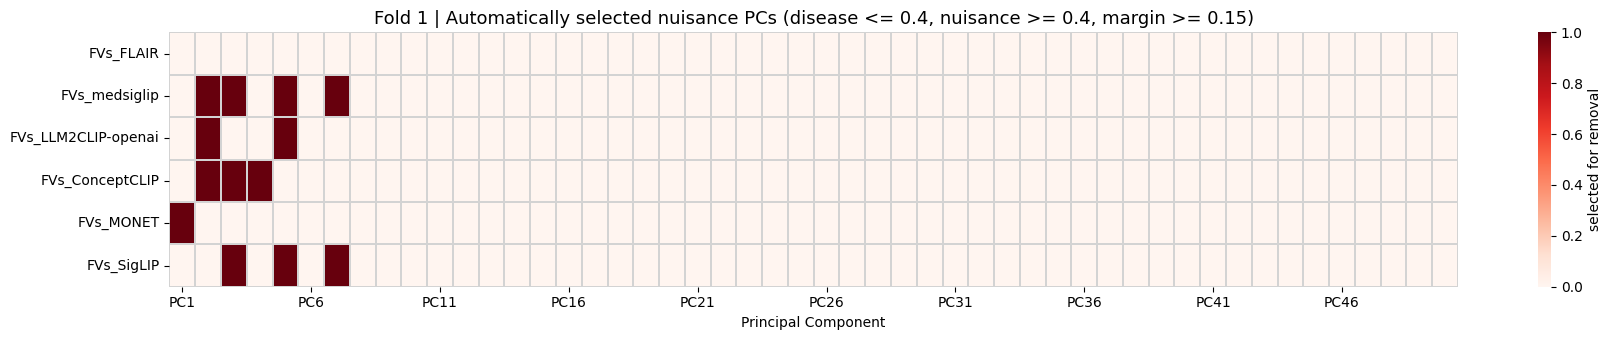

Saved: ./cv_pca_factor_heatmaps_sample\fold01_selected_nuisance_pc_heatmap.png


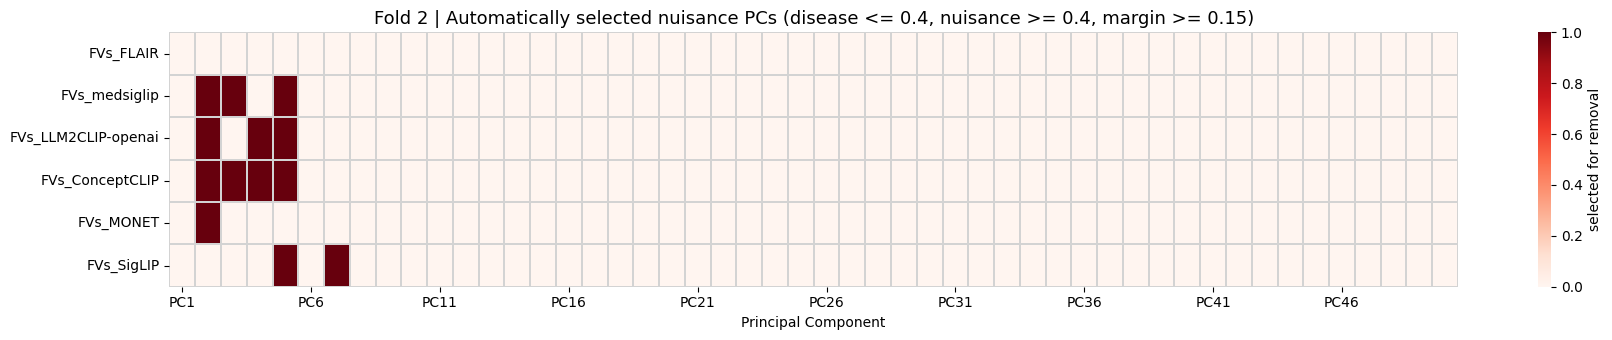

Saved: ./cv_pca_factor_heatmaps_sample\fold02_selected_nuisance_pc_heatmap.png


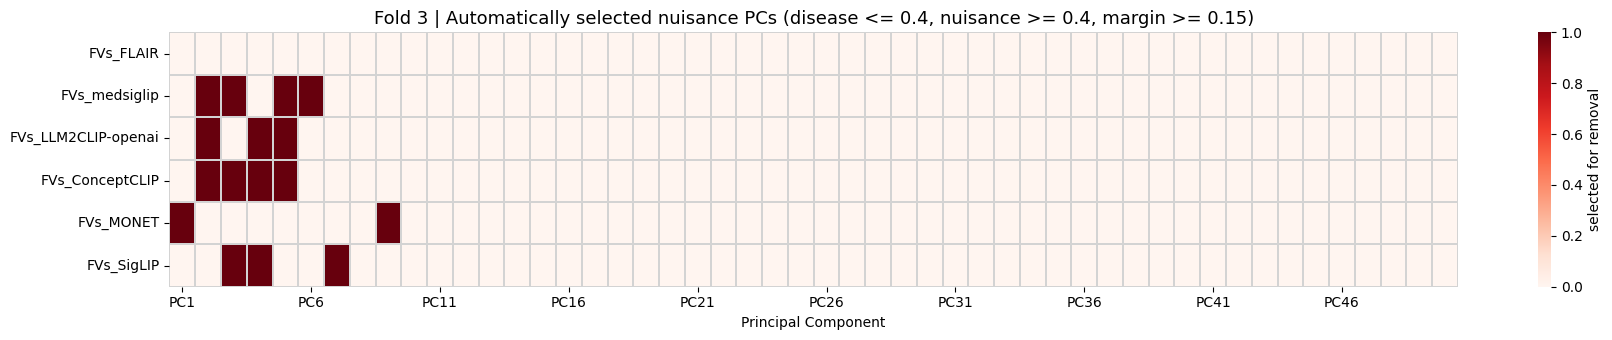

Saved: ./cv_pca_factor_heatmaps_sample\fold03_selected_nuisance_pc_heatmap.png


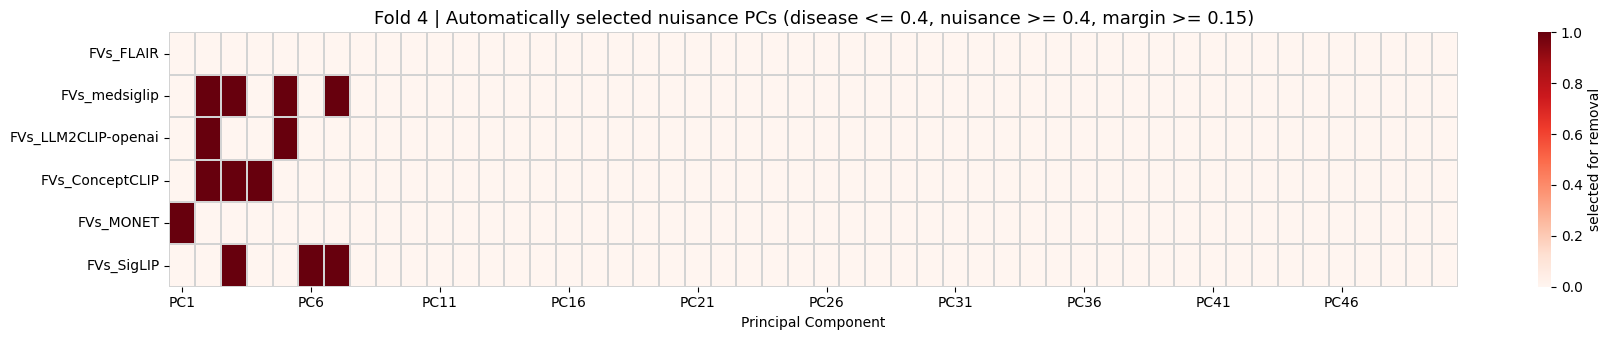

Saved: ./cv_pca_factor_heatmaps_sample\fold04_selected_nuisance_pc_heatmap.png


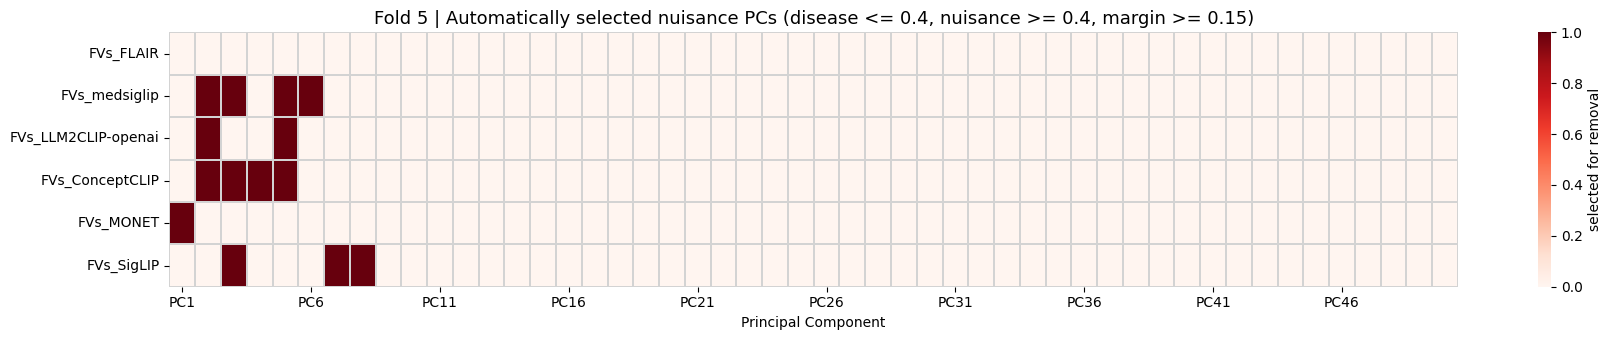

Saved: ./cv_pca_factor_heatmaps_sample\fold05_selected_nuisance_pc_heatmap.png


In [3]:
# =========================
# Automatic nuisance PC selection
# =========================
# 目的：
# train fold 内で算出した AUC / Spearman の結果から、
# 「非病変情報が強く、DR病変関連性が相対的に低いPC」を自動選択する。

from IPython.display import display

# -------------------------
# Selection config
# -------------------------

AUC_NUISANCE_FACTORS = [
    "view_no",
    "Overall quality",
    "eye",
]

SPEARMAN_NUISANCE_FACTORS = [
    "Clarity",
    "Field definition",
    "Artifact",
]

DISEASE_FACTOR = "eye_DR_Level"

DISEASE_MAX_TH = 0.40
NUISANCE_MIN_TH = 0.40
MARGIN_TH = 0.15

# None: 条件を満たしたPCを全部選ぶ
# 例: 5 にすると，各 model/fold で priority 上位5個までに制限
MAX_REMOVE_PCS_PER_FOLD = None

SELECTION_SUBSET = "train"


def _empty_max_df(extra_cols):
    return pd.DataFrame(columns=["model_name", "fold", "PC"] + extra_cols)


def _take_group_max(df, score_col, keep_cols):
    """
    model_name / fold / PC ごとに score_col が最大の行を取る。
    """
    if df.empty:
        return _empty_max_df(keep_cols)

    tmp = df.dropna(subset=[score_col]).copy()
    if tmp.empty:
        return _empty_max_df(keep_cols)

    idx = tmp.groupby(["model_name", "fold", "PC"])[score_col].idxmax()
    return tmp.loc[idx, ["model_name", "fold", "PC"] + keep_cols].reset_index(drop=True)


def build_nuisance_pc_score_table(
    auc_factor_df,
    spearman_factor_df,
    subset="train",
):
    """
    各PCについて nuisance_score / disease_score / remove_candidate を計算する。

    nuisance_score:
        AUC系: 2 * |AUC_raw - 0.5|
        Spearman系: |rho|

    disease_score:
        eye_DR_Level との |Spearman rho|

    remove_candidate:
        disease_score <= 0.40
        nuisance_score >= 0.40
        nuisance_score - disease_score >= 0.15
    """

    key_cols = ["model_name", "fold", "PC"]

    # -------------------------
    # AUC nuisance strength
    # -------------------------
    auc_tmp = auc_factor_df[
        (auc_factor_df["subset"] == subset) &
        (auc_factor_df["factor"].isin(AUC_NUISANCE_FACTORS))
    ].copy()

    if not auc_tmp.empty:
        auc_tmp["auc_nuisance_strength"] = 2.0 * auc_tmp["abs_AUC_minus_0.5"].abs()

    auc_max = _take_group_max(
        auc_tmp,
        score_col="auc_nuisance_strength",
        keep_cols=["factor", "auc_nuisance_strength", "AUC_raw"],
    ).rename(columns={
        "factor": "auc_nuisance_factor",
        "auc_nuisance_strength": "auc_nuisance_score",
        "AUC_raw": "auc_nuisance_AUC_raw",
    })

    # -------------------------
    # Spearman nuisance strength
    # -------------------------
    sp_nuisance_tmp = spearman_factor_df[
        (spearman_factor_df["subset"] == subset) &
        (spearman_factor_df["factor"].isin(SPEARMAN_NUISANCE_FACTORS))
    ].copy()

    if not sp_nuisance_tmp.empty:
        sp_nuisance_tmp["spearman_nuisance_strength"] = sp_nuisance_tmp["abs_spearman_rho"].abs()

    sp_nuisance_max = _take_group_max(
        sp_nuisance_tmp,
        score_col="spearman_nuisance_strength",
        keep_cols=["factor", "spearman_nuisance_strength", "spearman_rho"],
    ).rename(columns={
        "factor": "spearman_nuisance_factor",
        "spearman_nuisance_strength": "spearman_nuisance_score",
        "spearman_rho": "spearman_nuisance_rho",
    })

    # -------------------------
    # Disease score
    # -------------------------
    disease_tmp = spearman_factor_df[
        (spearman_factor_df["subset"] == subset) &
        (spearman_factor_df["factor"] == DISEASE_FACTOR)
    ].copy()

    if not disease_tmp.empty:
        disease_tmp["disease_score"] = disease_tmp["abs_spearman_rho"].abs()

    disease_score_df = _take_group_max(
        disease_tmp,
        score_col="disease_score",
        keep_cols=["disease_score", "spearman_rho"],
    ).rename(columns={
        "spearman_rho": "disease_rho",
    })

    # -------------------------
    # Merge all keys
    # -------------------------
    base_parts = []
    for df in [auc_max, sp_nuisance_max, disease_score_df]:
        if not df.empty:
            base_parts.append(df[key_cols])

    if len(base_parts) == 0:
        return pd.DataFrame()

    score_df = pd.concat(base_parts, ignore_index=True).drop_duplicates()

    score_df = score_df.merge(auc_max, on=key_cols, how="left")
    score_df = score_df.merge(sp_nuisance_max, on=key_cols, how="left")
    score_df = score_df.merge(disease_score_df, on=key_cols, how="left")

    for col in ["auc_nuisance_score", "spearman_nuisance_score", "disease_score"]:
        score_df[col] = score_df[col].fillna(0.0)

    # nuisance_score = max(AUC nuisance, Spearman nuisance)
    score_df["nuisance_score"] = score_df[
        ["auc_nuisance_score", "spearman_nuisance_score"]
    ].max(axis=1)

    score_df["nuisance_source"] = np.where(
        score_df["auc_nuisance_score"] >= score_df["spearman_nuisance_score"],
        "AUC",
        "Spearman",
    )

    score_df["nuisance_factor"] = np.where(
        score_df["nuisance_source"] == "AUC",
        score_df["auc_nuisance_factor"],
        score_df["spearman_nuisance_factor"],
    )

    score_df["priority"] = score_df["nuisance_score"] - score_df["disease_score"]

    score_df["is_remove_candidate"] = (
        (score_df["disease_score"] <= DISEASE_MAX_TH) &
        (score_df["nuisance_score"] >= NUISANCE_MIN_TH) &
        (score_df["priority"] >= MARGIN_TH)
    )

    score_df["PC_num"] = score_df["PC"].str.replace("PC", "", regex=False).astype(int)

    score_df = score_df.sort_values(
        ["model_name", "fold", "is_remove_candidate", "priority", "nuisance_score", "PC_num"],
        ascending=[True, True, False, False, False, True],
    ).reset_index(drop=True)

    return score_df


def build_remove_plan(pc_score_df, max_remove_pcs_per_fold=None):
    """
    remove_candidate の中から，実際に削除するPCリストを model/fold ごとに作る。
    """
    key_cols = ["model_name", "fold", "PC"]

    candidates = pc_score_df[pc_score_df["is_remove_candidate"]].copy()
    candidates = candidates.sort_values(
        ["model_name", "fold", "priority", "nuisance_score", "PC_num"],
        ascending=[True, True, False, False, True],
    )

    if max_remove_pcs_per_fold is not None:
        selected = (
            candidates
            .groupby(["model_name", "fold"], group_keys=False)
            .head(max_remove_pcs_per_fold)
            .copy()
        )
    else:
        selected = candidates.copy()

    pc_score_df = pc_score_df.copy()
    if selected.empty:
        pc_score_df["selected_for_removal"] = False
    else:
        selected_index = pd.MultiIndex.from_frame(selected[key_cols])
        score_index = pd.MultiIndex.from_frame(pc_score_df[key_cols])
        pc_score_df["selected_for_removal"] = score_index.isin(selected_index)

    all_groups = (
        pc_score_df[["model_name", "fold"]]
        .drop_duplicates()
        .sort_values(["model_name", "fold"])
        .reset_index(drop=True)
    )

    if selected.empty:
        remove_plan_df = all_groups.copy()
        remove_plan_df["remove_pcs"] = ""
        remove_plan_df["remove_pc_nums"] = ""
        remove_plan_df["n_remove"] = 0
        return pc_score_df, selected, remove_plan_df

    remove_plan_df = (
        selected
        .sort_values(["model_name", "fold", "PC_num"])
        .groupby(["model_name", "fold"])
        .agg(
            remove_pcs=("PC", lambda x: ",".join(x)),
            remove_pc_nums=("PC_num", lambda x: ",".join(map(str, x))),
            n_remove=("PC", "size"),
            max_nuisance_score=("nuisance_score", "max"),
            max_disease_score=("disease_score", "max"),
            max_priority=("priority", "max"),
            main_nuisance_factors=("nuisance_factor", lambda x: ",".join(pd.Series(x).dropna().astype(str).unique())),
        )
        .reset_index()
    )

    remove_plan_df = all_groups.merge(
        remove_plan_df,
        on=["model_name", "fold"],
        how="left",
    )

    remove_plan_df["remove_pcs"] = remove_plan_df["remove_pcs"].fillna("")
    remove_plan_df["remove_pc_nums"] = remove_plan_df["remove_pc_nums"].fillna("")
    remove_plan_df["n_remove"] = remove_plan_df["n_remove"].fillna(0).astype(int)

    return pc_score_df, selected, remove_plan_df


def build_stable_remove_summary(selected_pc_df):
    """
    各PCが5 fold中何回選ばれたかを集計する。
    """
    if selected_pc_df.empty:
        return pd.DataFrame(columns=[
            "model_name", "PC", "PC_num", "selected_count", "n_folds", "selection_rate"
        ])

    n_folds_df = (
        selected_pc_df[["model_name", "fold"]]
        .drop_duplicates()
        .groupby("model_name")
        .size()
        .reset_index(name="n_folds")
    )

    stable_df = (
        selected_pc_df
        .groupby(["model_name", "PC", "PC_num"])
        .agg(
            selected_count=("fold", "nunique"),
            mean_nuisance_score=("nuisance_score", "mean"),
            mean_disease_score=("disease_score", "mean"),
            mean_priority=("priority", "mean"),
            nuisance_factors=("nuisance_factor", lambda x: ",".join(pd.Series(x).dropna().astype(str).unique())),
        )
        .reset_index()
    )

    stable_df = stable_df.merge(n_folds_df, on="model_name", how="left")
    stable_df["selection_rate"] = stable_df["selected_count"] / stable_df["n_folds"]

    stable_df = stable_df.sort_values(
        ["model_name", "selection_rate", "selected_count", "mean_priority", "PC_num"],
        ascending=[True, False, False, False, True],
    ).reset_index(drop=True)

    return stable_df


def plot_selected_pc_heatmap(pc_score_df, out_dir):
    """
    fold ごとに selected_for_removal のPCを可視化する。
    """
    pc_order = [f"PC{i}" for i in range(1, N_PC + 1)]

    for fold in sorted(pc_score_df["fold"].unique()):
        tmp = pc_score_df[pc_score_df["fold"] == fold].copy()
        tmp["row_name"] = tmp["model_name"]

        mat = tmp.pivot_table(
            index="row_name",
            columns="PC",
            values="selected_for_removal",
            aggfunc="max",
            fill_value=False,
        ).astype(int)

        mat = mat.reindex(index=MODEL_NAMES)
        mat = mat.reindex(columns=pc_order)

        out_path = os.path.join(
            out_dir,
            f"fold{fold:02d}_selected_nuisance_pc_heatmap.png"
        )

        plt.figure(figsize=(18, 3.5))
        sns.heatmap(
            mat,
            cmap="Reds",
            vmin=0,
            vmax=1,
            linewidths=0.2,
            linecolor="lightgray",
            xticklabels=5,
            yticklabels=True,
            cbar_kws={"label": "selected for removal"},
        )
        plt.title(
            f"Fold {fold} | Automatically selected nuisance PCs "
            f"(disease <= {DISEASE_MAX_TH}, nuisance >= {NUISANCE_MIN_TH}, margin >= {MARGIN_TH})",
            fontsize=13,
        )
        plt.xlabel("Principal Component")
        plt.ylabel("")
        plt.tight_layout()
        plt.savefig(out_path, dpi=300)
        plt.show()

        print(f"Saved: {out_path}")


# =========================
# Run automatic selection
# =========================

pc_score_df = build_nuisance_pc_score_table(
    auc_factor_df=auc_factor_df,
    spearman_factor_df=spearman_factor_df,
    subset=SELECTION_SUBSET,
)

pc_score_df, selected_pc_df, remove_plan_df = build_remove_plan(
    pc_score_df,
    max_remove_pcs_per_fold=MAX_REMOVE_PCS_PER_FOLD,
)

stable_remove_summary_df = build_stable_remove_summary(selected_pc_df)

# Save results
pc_score_csv = os.path.join(OUT_DIR, "pc_nuisance_disease_score_table.csv")
selected_pc_csv = os.path.join(OUT_DIR, "selected_nuisance_pc_long.csv")
remove_plan_csv = os.path.join(OUT_DIR, "selected_nuisance_pc_remove_plan.csv")
stable_summary_csv = os.path.join(OUT_DIR, "selected_nuisance_pc_stability_summary.csv")

pc_score_df.to_csv(pc_score_csv, index=False)
selected_pc_df.to_csv(selected_pc_csv, index=False)
remove_plan_df.to_csv(remove_plan_csv, index=False)
stable_remove_summary_df.to_csv(stable_summary_csv, index=False)

print(f"Saved: {pc_score_csv}")
print(f"Saved: {selected_pc_csv}")
print(f"Saved: {remove_plan_csv}")
print(f"Saved: {stable_summary_csv}")

print("\n=== Remove plan by model/fold ===")
display(remove_plan_df)

print("\n=== Selected nuisance PCs, long format ===")
display(selected_pc_df[[
    "model_name", "fold", "PC", "PC_num",
    "nuisance_score", "disease_score", "priority",
    "nuisance_source", "nuisance_factor",
    "auc_nuisance_score", "spearman_nuisance_score",
    "disease_rho",
]].sort_values(["model_name", "fold", "PC_num"]))

print("\n=== Stability summary across folds ===")
display(stable_remove_summary_df)

plot_selected_pc_heatmap(pc_score_df, OUT_DIR)

In [ ]:
# ============================================================
# Performance analysis:
# Baseline vs Remove nuisance PCs vs Random removal
# ============================================================

import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.metrics import cohen_kappa_score, accuracy_score, f1_score
from sklearn.model_selection import GroupKFold, StratifiedKFold

from sklearn.pipeline import make_pipeline



# =========================
# Config
# =========================

PERF_OUT_DIR = os.path.join(OUT_DIR, "performance_analysis")
os.makedirs(PERF_OUT_DIR, exist_ok=True)

# 这里建议用 eye_DR_Level
# 如果你后面决定用 patient_DR_Level，就改这里
TARGET_COL = "eye_DR_Level"

N_RANDOM_REPEATS = 20
CLASSIFIER_C = 0.1
MAX_ITER = 20000


# =========================
# Helper functions
# =========================

def parse_remove_pcs(x):
    """
    remove_plan_df 里的 remove_pcs 有时是 list，有时从 csv 读出来会变成字符串。
    这个函数统一转成 list。
    """
    if isinstance(x, list):
        return x

    if pd.isna(x):
        return []

    if isinstance(x, str):
        x = x.strip()
        if x == "" or x == "[]":
            return []
        try:
            val = ast.literal_eval(x)
            if isinstance(val, list):
                return val
        except Exception:
            pass

        # fallback: "PC1,PC2" 这种
        return [p.strip() for p in x.split(",") if p.strip()]

    return []


def pc_names_to_indices(remove_pcs, n_components):
    indices = []

    for pc in remove_pcs:
        if isinstance(pc, str) and pc.startswith("PC"):
            idx = int(pc.replace("PC", "")) - 1
        else:
            idx = int(pc) - 1

        if 0 <= idx < n_components:
            indices.append(idx)

    return sorted(list(set(indices)))


def remove_pcs_by_zeroing(Z, remove_indices):
    """
    PCA score の指定PCを0にする。
    """
    Z_new = Z.copy()
    if len(remove_indices) > 0:
        Z_new[:, remove_indices] = 0.0
    return Z_new


# def train_eval_classifier(X_train, y_train, X_valid, y_valid):
#     clf = LinearSVC(
#         C=CLASSIFIER_C,
#         class_weight="balanced",
#         max_iter=MAX_ITER,
#         random_state=RANDOM_STATE,
#     )

#     clf.fit(X_train, y_train)
#     pred = clf.predict(X_valid)

#     qwk = cohen_kappa_score(y_valid, pred, weights="quadratic")
#     acc = accuracy_score(y_valid, pred)
#     macro_f1 = f1_score(y_valid, pred, average="macro", zero_division=0)

#     return {
#         "qwk": qwk,
#         "accuracy": acc,
#         "macro_f1": macro_f1,
#     }
def train_eval_classifier(X_train, y_train, X_valid, y_valid):
    clf = make_pipeline(
        StandardScaler(),
        LinearSVC(
            C=CLASSIFIER_C,
            class_weight="balanced",
            max_iter=MAX_ITER,
            tol=1e-3,
            random_state=RANDOM_STATE,
        )
    )

    clf.fit(X_train, y_train)
    pred = clf.predict(X_valid)

    return {
        "qwk": cohen_kappa_score(y_valid, pred, weights="quadratic"),
        "accuracy": accuracy_score(y_valid, pred),
        "macro_f1": f1_score(y_valid, pred, average="macro", zero_division=0),
    }


def get_remove_pcs_for_fold(remove_plan_df, model_name, fold):
    row = remove_plan_df[
        (remove_plan_df["model_name"] == model_name) &
        (remove_plan_df["fold"] == fold)
    ]

    if len(row) == 0:
        return []

    return parse_remove_pcs(row.iloc[0]["remove_pcs"])


def filter_target_available(X, meta_df, target_col):
    y = pd.to_numeric(meta_df[target_col], errors="coerce")
    mask = y.notna().values

    X_new = X[mask]
    meta_new = meta_df.loc[mask].reset_index(drop=True)
    meta_new[target_col] = pd.to_numeric(meta_new[target_col], errors="coerce").astype(int)

    return X_new, meta_new


# =========================
# Main performance loop
# =========================

performance_rows = []
random_rows = []

for model_name in MODEL_NAMES:
    print(f"\n===== Performance analysis: {model_name} =====")

    X, meta_df = load_features_and_meta(model_name)

    if TARGET_COL not in meta_df.columns:
        raise ValueError(f"{model_name}: TARGET_COL '{TARGET_COL}' not found.")

    X, meta_df = filter_target_available(X, meta_df, TARGET_COL)
    y_all = meta_df[TARGET_COL].astype(int).values

    cv_splits = make_cv_splits(meta_df)

    for fold_idx, (train_idx, valid_idx) in enumerate(cv_splits, start=1):
        print(f"  Fold {fold_idx}: train={len(train_idx)}, valid={len(valid_idx)}")

        X_train = X[train_idx]
        X_valid = X[valid_idx]

        y_train = y_all[train_idx]
        y_valid = y_all[valid_idx]

        # -------------------------
        # Fit scaler and PCA only on train fold
        # -------------------------
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_valid_scaled = scaler.transform(X_valid)

        n_pc_eff = min(N_PC, X_train_scaled.shape[0] - 1, X_train_scaled.shape[1])

        pca = PCA(n_components=n_pc_eff, random_state=RANDOM_STATE)
        Z_train = pca.fit_transform(X_train_scaled)
        Z_valid = pca.transform(X_valid_scaled)

        # -------------------------
        # Baseline: original scaled features
        # -------------------------
        # baseline_metrics = train_eval_classifier(
        #     X_train_scaled,
        #     y_train,
        #     X_valid_scaled,
        #     y_valid,
        # )

        # performance_rows.append({
        #     "model_name": model_name,
        #     "fold": fold_idx,
        #     "method": "baseline_raw_scaled",
        #     "n_removed": 0,
        #     "removed_pcs": [],
        #     **baseline_metrics,
        # })
        baseline_metrics = train_eval_classifier(
            Z_train,
            y_train,
            Z_valid,
            y_valid,
        )

        performance_rows.append({
            "model_name": model_name,
            "fold": fold_idx,
            "method": "pca_all_pc",
            "n_removed": 0,
            "removed_pcs": [],
            **baseline_metrics,
        })

        # -------------------------
        # Sanity: PCA reconstruct all PCs
        # -------------------------
        X_train_recon_all = pca.inverse_transform(Z_train)
        X_valid_recon_all = pca.inverse_transform(Z_valid)

        recon_metrics = train_eval_classifier(
            X_train_recon_all,
            y_train,
            X_valid_recon_all,
            y_valid,
        )

        performance_rows.append({
            "model_name": model_name,
            "fold": fold_idx,
            "method": "pca_reconstruct_all",
            "n_removed": 0,
            "removed_pcs": [],
            **recon_metrics,
        })

        # -------------------------
        # Remove automatically selected nuisance PCs
        # -------------------------
        remove_pcs = get_remove_pcs_for_fold(remove_plan_df, model_name, fold_idx)
        remove_indices = pc_names_to_indices(remove_pcs, n_components=n_pc_eff)

        Z_train_removed = remove_pcs_by_zeroing(Z_train, remove_indices)
        Z_valid_removed = remove_pcs_by_zeroing(Z_valid, remove_indices)

        # X_train_removed = pca.inverse_transform(Z_train_removed)
        # X_valid_removed = pca.inverse_transform(Z_valid_removed)

        nuisance_metrics = train_eval_classifier(
            Z_train_removed,
            y_train,
            Z_valid_removed,
            y_valid,
        )

        performance_rows.append({
            "model_name": model_name,
            "fold": fold_idx,
            "method": "remove_nuisance_pc",
            "n_removed": len(remove_indices),
            "removed_pcs": remove_pcs,
            **nuisance_metrics,
        })

        # -------------------------
        # Random removal:
        # remove the same number of PCs as nuisance removal
        # -------------------------
        n_remove = len(remove_indices)

        if n_remove > 0:
            candidate_indices = np.arange(n_pc_eff)

            # disease PC を random から除外したい場合はここで制御できる
            # 今回は単純に全PCから同数をランダム削除
            for rep in range(N_RANDOM_REPEATS):
                rng = np.random.default_rng(RANDOM_STATE + 1000 * fold_idx + rep)

                random_indices = sorted(
                    rng.choice(candidate_indices, size=n_remove, replace=False).tolist()
                )

                random_pcs = [f"PC{i+1}" for i in random_indices]

                Z_train_random = remove_pcs_by_zeroing(Z_train, random_indices)
                Z_valid_random = remove_pcs_by_zeroing(Z_valid, random_indices)

                # X_train_random = pca.inverse_transform(Z_train_random)
                # X_valid_random = pca.inverse_transform(Z_valid_random)

                random_metrics = train_eval_classifier(
                    Z_train_random,
                    y_train,
                    Z_valid_random,
                    y_valid,
                )

                random_rows.append({
                    "model_name": model_name,
                    "fold": fold_idx,
                    "method": "remove_random_pc",
                    "repeat": rep,
                    "n_removed": n_remove,
                    "removed_pcs": random_pcs,
                    **random_metrics,
                })

        else:
            # nuisance PC がない fold では random removal も比較対象なし
            random_rows.append({
                "model_name": model_name,
                "fold": fold_idx,
                "method": "remove_random_pc",
                "repeat": np.nan,
                "n_removed": 0,
                "removed_pcs": [],
                "qwk": np.nan,
                "accuracy": np.nan,
                "macro_f1": np.nan,
            })


performance_df = pd.DataFrame(performance_rows)
random_performance_df = pd.DataFrame(random_rows)

performance_csv = os.path.join(PERF_OUT_DIR, "performance_baseline_nuisance.csv")
random_csv = os.path.join(PERF_OUT_DIR, "performance_random_removal.csv")

performance_df.to_csv(performance_csv, index=False)
random_performance_df.to_csv(random_csv, index=False)

print(f"\nSaved: {performance_csv}")
print(f"Saved: {random_csv}")

display(performance_df.head())
display(random_performance_df.head())


===== Performance analysis: FVs_FLAIR =====
  Fold 1: train=949, valid=240
  Fold 2: train=951, valid=238
  Fold 3: train=951, valid=238
  Fold 4: train=952, valid=237
  Fold 5: train=953, valid=236

===== Performance analysis: FVs_medsiglip =====
  Fold 1: train=949, valid=240


c:\M1\test_DR\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  Fold 2: train=951, valid=238


c:\M1\test_DR\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  Fold 3: train=951, valid=238


...

  Fold 5: train=953, valid=236


c:\M1\test_DR\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



===== Performance analysis: FVs_LLM2CLIP-openai =====
  Fold 1: train=949, valid=240


c:\M1\test_DR\.venv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  Fold 2: train=951, valid=238
